In [ ]:
pip install -U finance-datareader

In [ ]:
# mq_quant.py

import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def calc_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance(daily_ret, cum_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

def get_rebalancing_dates(close_data, period="month"):
    """
    리밸런싱 날짜 추출 (Pandas Grouper 활용)
    - 입력: 종가 데이터, 주기('month', 'quarter', 'year')
    - 출력: 리밸런싱 시행일(DatetimeIndex)
    """
    # 주기별 Pandas Frequency 문자열 매핑
    freq_map = {'month': 'ME', 'quarter': 'QE', 'year': 'YE'}

    # 1. 예외처리: 잘못된 주기 입력
    if period not in freq_map:
        raise ValueError("period must be 'month', 'quarter', or 'year'")

    freq = freq_map[period]

    rebalancing_dates = close_data.groupby(pd.Grouper(freq=freq)).apply(lambda x: x.index[-1])

    return rebalancing_dates.sort_index()


def cal_rebalancing_portfolio(close_data, period="month", weight_df=None, enable_plot=True):
    """
    리밸런싱 포트폴리오 성과 계산 (Chunk 방식)
    """

    # 1. 리밸런싱 날짜 구하기 (전체 데이터 기준)
    rebal_dates = get_rebalancing_dates(close_data, period)

    # 날짜 동기화 (weight_df가 있다면, 교집합 날짜만 사용)
    # close_data가 더 길어도, weight_df가 있는 기간만 백테스팅 수행
    if weight_df is not None:
        # weight_df 인덱스에 포함된 날짜만 필터링
        rebal_dates = rebal_dates[rebal_dates.isin(weight_df.index)]

        # 만약 겹치는 날짜가 하나도 없다면 에러 처리
        if rebal_dates.empty:
            print("Error: close_data와 weight_df의 리밸런싱 날짜가 일치하지 않습니다.")
            return None, None

    # 3. 초기 비중 설정 (없으면 동일 비중)
    if weight_df is None:
        n_assets = len(close_data.columns)
        weight_df = pd.DataFrame(
            index=rebal_dates,
            columns=close_data.columns,
            data=1/n_assets
        )

    # 4. 데이터 범위 보정 (시작일 기준)
    first_date = rebal_dates[0] # 필터링된 첫 날짜


    # 전체 기간 수익률 계산
    full_daily_rets = close_data.pct_change().fillna(0)

    # 백테스트 시작일 이후 데이터만 슬라이싱
    daily_rets = full_daily_rets.loc[first_date:]

    portfolio_chunks = []
    total_value = 1.0

    # 리밸런싱 기간별 순회
    full_dates = list(rebal_dates)

    # 마지막 구간 처리: 마지막 리밸런싱 날짜 ~ 데이터 끝 날짜
    # (단, daily_rets의 마지막 날짜가 리밸런싱 날짜보다 뒤에 있을 때만)
    if full_dates[-1] < daily_rets.index[-1]:
        full_dates.append(daily_rets.index[-1])

    for start, end in zip(full_dates[:-1], full_dates[1:]):

        # start가 weight_df에 없으면 건너뜀 (안전 장치)
        if start not in weight_df.index:
            continue

        current_weights = weight_df.loc[start]

        # start 다음날부터 end까지의 수익률 사용 (start 당일은 리밸런싱 날)
        chunk_rets = daily_rets.loc[start:end].iloc[1:]

        if chunk_rets.empty: continue

        cum_growth = (1 + chunk_rets).cumprod()
        chunk_value = (cum_growth * current_weights).sum(axis=1) * total_value
        portfolio_chunks.append(chunk_value)
        total_value = chunk_value.iloc[-1]

    # 6. 결과 병합
    if not portfolio_chunks:
        return None, None

    portfolio_cum_ret = pd.concat(portfolio_chunks)
    portfolio_cum_ret.loc[first_date] = 1.0 # 시작점 1.0 강제 할당
    portfolio_cum_ret = portfolio_cum_ret.sort_index()

    portfolio_day_ret = portfolio_cum_ret.pct_change().fillna(0)

    if enable_plot:
        historical_max = portfolio_cum_ret.cummax()
        dd = (portfolio_cum_ret - historical_max) / historical_max * 100
        mdd = dd.min()

        # [수정] 전체 컬럼이 아니라, weight_df에 존재하는(실제 투자된) 티커만 추출
        if weight_df is not None:
            # weight_df의 컬럼 중 close_data에도 존재하는 것만 리스트로 만듦 (KeyError 방지)
            tickers = [col for col in weight_df.columns if col in close_data.columns]

            if 'cash' in tickers: tickers.remove('cash')
        else:
            tickers = close_data.columns.tolist()

        plot_daily_rets = full_daily_rets.loc[portfolio_cum_ret.index]

        plot_portfolio_result(tickers, plot_daily_rets, portfolio_cum_ret, dd, mdd)

    return portfolio_day_ret, portfolio_cum_ret


def plot_portfolio_result(tickers, daily_rets, port_cum_ret, dd, mdd):
    """
    포트폴리오 성과 시각화 함수 (백테스트 기간 일치 버전)
    """

    plt.figure(figsize=(10, 8))

    # [차트 1] 포트폴리오 누적 수익률 (Asset Growth)
    plt.subplot(2, 1, 1)

    # 1. 메인 포트폴리오 선 그리기
    plt.plot(port_cum_ret.index, port_cum_ret, label='Portfolio', color='#d62728', linewidth=1.5)

    # 2. 개별 종목 흐름 그리기 (기간 매칭 및 리베이스)
    if daily_rets is not None and tickers is not None:

        # [핵심 수정] 포트폴리오의 시작/종료 날짜 구하기
        start_date = port_cum_ret.index[0]
        end_date = port_cum_ret.index[-1]

        # [핵심 수정] 전체 데이터(daily_rets)를 실제 백테스트 기간만큼만 자르기
        subset_daily_rets = daily_rets.loc[start_date:end_date]

        for t in tickers:
            if t in subset_daily_rets.columns:
                # [핵심 수정] 잘라낸 기간의 수익률로 누적 수익률 새로 계산
                # 이렇게 해야 시작점이 1.0(혹은 포트폴리오 시작점) 근처로 맞춰집니다.
                ind_cum = (1 + subset_daily_rets[t]).cumprod()

                # 시각화 (투명도 조절)
                plt.plot(ind_cum.index, ind_cum, label=f'{t}', alpha=0.3, linewidth=0.8, linestyle='--')

    # Y축 로그 스케일 및 포맷 설정
    plt.yscale('log')
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

    plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
    plt.title('Portfolio Cumulative Return', fontsize=14, fontweight='bold')

    # 범례가 너무 많으면 가리니까, 적절히 위치 조정
    plt.legend(loc='upper left', fontsize='small')
    plt.grid(True, alpha=0.3)


    # [차트 2] 낙폭 (Drawdown)
    plt.subplot(2, 1, 2)

    plt.fill_between(dd.index, dd, 0, color='#1f77b4', alpha=0.3)
    plt.plot(dd.index, dd, color='#1f77b4', linewidth=0.5)

    plt.title('Portfolio Drawdown (MDD)', fontsize=12)
    plt.axhline(mdd, color='red', linestyle='--', label=f'Max DD: {mdd:.2f}%')

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Drawdown (%)')

    plt.tight_layout()
    plt.show()

## GTAA

1. 투자 대상:  SPY(S&P500), EFA(선진국 주식), IEF(미국 중기채), DBC(원자재), VNQ(미국 리츠)


2. 5개 자산에 각 20% 비중으로 투자하되, 모멘텀 스코어 0 미만인 자산은 현금 보유
* 모멘텀 스코어 = (가격 / 200일 이동평균) - 1

3. 매월 말 리밸런싱

In [ ]:
# 데이터 다시 불러오기 (Reload Data)
close_data = pd.read_csv('/content/ETF 유니버스.csv', index_col=0, parse_dates=True)
close_data = close_data.loc['2009-01-01':]

# 확인
print(f"Data loaded. Start: {close_data.index[0]}, End: {close_data.index[-1]}")
close_data

Data loaded. Start: 2009-01-02 00:00:00, End: 2026-01-07 00:00:00


,SPY,QQQ,IWM,DIA,VUG,IWO,VTV,IWN,USMV,QUAL,...,WGMI,BLOK,BIL,SGOV,NEAR,MINT,ICSH,JPST,PULS,VNQ.1
Date,,,,,,,,,,,,,,,,,,,,,
2009-01-02,68.17,26.82,39.86,62.00,34.08,45.60,27.27,35.29,NaN,NaN,...,NaN,NaN,74.80,NaN,NaN,NaN,NaN,NaN,NaN,17.78
2009-01-05,68.09,26.81,40.01,61.66,34.16,45.97,27.13,35.38,NaN,NaN,...,NaN,NaN,74.80,NaN,NaN,NaN,NaN,NaN,NaN,17.46
2009-01-06,68.54,27.08,40.68,61.97,34.50,46.60,27.34,35.97,NaN,NaN,...,NaN,NaN,74.82,NaN,NaN,NaN,NaN,NaN,NaN,18.33
2009-01-07,66.49,26.31,39.48,60.39,33.63,45.31,26.45,34.91,NaN,NaN,...,NaN,NaN,74.94,NaN,NaN,NaN,NaN,NaN,NaN,17.71
2009-01-08,66.76,26.59,39.67,60.10,33.73,45.52,26.56,35.19,NaN,NaN,...,NaN,NaN,74.85,NaN,NaN,NaN,NaN,NaN,NaN,17.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,681.92,614.31,246.16,480.57,487.86,323.01,190.99,181.21,94.16,198.62,...,38.27,56.89,91.38,100.38,51.10,100.34,50.58,50.59,49.59,88.49
2026-01-02,683.17,613.12,248.78,483.63,486.20,327.12,192.81,182.87,93.65,199.19,...,42.05,59.24,91.42,100.41,51.12,100.37,50.58,50.62,49.62,88.52
2026-01-05,687.72,617.99,252.73,489.77,488.45,333.36,194.65,185.19,94.00,201.18,...,45.96,62.49,91.42,100.42,51.15,100.37,50.60,50.61,49.62,88.72


In [ ]:
# 데이터 준비
gtaaCol = ['SPY', 'EFA', "IEF", "DBC", "VNQ"]
gtaaData = close_data[gtaaCol]
gtaaData

,SPY,EFA,IEF,DBC,VNQ
Date,,,,,
2009-01-02,68.17,27.30,65.62,18.54,17.78
2009-01-05,68.09,26.86,65.51,18.73,17.46
2009-01-06,68.54,27.15,65.47,19.23,18.33
2009-01-07,66.49,26.68,65.48,18.24,17.71
2009-01-08,66.76,27.08,65.66,18.31,17.58
...,...,...,...,...,...
2025-12-31,681.92,96.03,96.16,22.36,88.49
2026-01-02,683.17,97.04,96.08,22.39,88.52
2026-01-05,687.72,98.15,96.37,22.81,88.72


### 모멘텀 스코어 계산

모멘텀 스코어 = (가격 / 200일 이동평균) - 1

**이동평균 계산?**

- pandas의 rolling을 사용하면 쉽게 계산할 수 있습니다.

In [ ]:
df = pd.DataFrame({'A': [0, 1, 2, 3, 4]})
df

,A
0,0
1,1
2,2
3,3
4,4


In [ ]:
df.rolling(window=2).mean()

,A
0,NaN
1,0.5
2,1.5
3,2.5
4,3.5


- 5개 자산에 각 20% 비중으로 투자하되, 모멘텀 스코어 0 미만인 자산의 비중만큼은 현금 보유
- 모멘텀 스코어 = (가격 / 200일 이동평균) - 1

In [ ]:
# 200일 이동평균
ma200 = gtaaData.rolling(window=200).mean()

In [ ]:
# 모멘텀 스코어
momentumScore = (gtaaData / ma200) -1
momentumScore.dropna(inplace=True)
momentumScore

,SPY,EFA,IEF,DBC,VNQ
Date,,,,,
2009-10-16,0.205053,0.257912,0.001447,0.114386,0.284533
2009-10-19,0.213751,0.276216,0.003172,0.129218,0.310973
2009-10-20,0.206182,0.267813,0.005663,0.122098,0.284936
2009-10-21,0.194298,0.261710,0.003439,0.145289,0.267726
2009-10-22,0.205077,0.272150,0.000601,0.153783,0.298879
...,...,...,...,...,...
2025-12-31,0.093663,0.089562,0.022222,0.042264,0.005490
2026-01-02,0.094539,0.100066,0.021134,0.043409,0.005789
2026-01-05,0.100707,0.111629,0.023977,0.062655,0.008013


In [ ]:
# weightDf 계산하기
# 5개 자산에 각 20% 비중으로 투자하되, 모멘텀 스코어 0 미만인 자산의 비중만큼은 현금 보유
np.where(momentumScore > 0, 0.2, 0)

array([[0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       ...,
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2]])

In [ ]:
# 리밸런싱 일자
rebalDate = get_rebalancing_dates(momentumScore)
rebalDate

,0
Date,
2009-10-31,2009-10-30
2009-11-30,2009-11-30
2009-12-31,2009-12-31
2010-01-31,2010-01-29
2010-02-28,2010-02-26
...,...
2025-09-30,2025-09-30
2025-10-31,2025-10-31
2025-11-30,2025-11-28


In [ ]:
gtaaWeightDf = pd.DataFrame(np.where(momentumScore > 0, 0.2, 0), index=momentumScore.index, columns=gtaaCol)
gtaaWeightDf = gtaaWeightDf.loc[rebalDate]
gtaaWeightDf

,SPY,EFA,IEF,DBC,VNQ
Date,,,,,
2009-10-30,0.2,0.2,0.2,0.2,0.2
2009-11-30,0.2,0.2,0.2,0.2,0.2
2009-12-31,0.2,0.2,0.0,0.2,0.2
2010-01-29,0.2,0.2,0.2,0.0,0.2
2010-02-26,0.2,0.2,0.2,0.2,0.2
...,...,...,...,...,...
2025-09-30,0.2,0.2,0.2,0.2,0.2
2025-10-31,0.2,0.2,0.2,0.2,0.2
2025-11-28,0.2,0.2,0.2,0.2,0.2


In [ ]:
# 리밸런싱 일자
rebalDate = get_rebalancing_dates(momentumScore)
rebalDate

,0
Date,
2009-10-31,2009-10-30
2009-11-30,2009-11-30
2009-12-31,2009-12-31
2010-01-31,2010-01-29
2010-02-28,2010-02-26
...,...
2025-09-30,2025-09-30
2025-10-31,2025-10-31
2025-11-30,2025-11-28


In [ ]:
# 모멘텀 스코어 0 미만인 자산의 비중만큼은 현금 보유
gtaaWeightDf['cash'] = 1 - gtaaWeightDf.sum(axis=1)
gtaaWeightDf

,SPY,EFA,IEF,DBC,VNQ,cash
Date,,,,,,
2009-10-30,0.2,0.2,0.2,0.2,0.2,0.0
2009-11-30,0.2,0.2,0.2,0.2,0.2,0.0
2009-12-31,0.2,0.2,0.0,0.2,0.2,0.2
2010-01-29,0.2,0.2,0.2,0.0,0.2,0.2
2010-02-26,0.2,0.2,0.2,0.2,0.2,0.0
...,...,...,...,...,...,...
2025-09-30,0.2,0.2,0.2,0.2,0.2,0.0
2025-10-31,0.2,0.2,0.2,0.2,0.2,0.0
2025-11-28,0.2,0.2,0.2,0.2,0.2,0.0


In [ ]:
gtaaWeightDf = gtaaWeightDf.loc['2011-01-01':]
gtaaWeightDf

,SPY,EFA,IEF,DBC,VNQ,cash
Date,,,,,,
2011-01-31,0.2,0.2,0.0,0.2,0.2,0.2
2011-02-28,0.2,0.2,0.0,0.2,0.2,0.2
2011-03-31,0.2,0.2,0.0,0.2,0.2,0.2
2011-04-29,0.2,0.2,0.0,0.2,0.2,0.2
2011-05-31,0.2,0.2,0.2,0.2,0.2,0.0
...,...,...,...,...,...,...
2025-09-30,0.2,0.2,0.2,0.2,0.2,0.0
2025-10-31,0.2,0.2,0.2,0.2,0.2,0.0
2025-11-28,0.2,0.2,0.2,0.2,0.2,0.0


In [ ]:
gtaaData

,SPY,EFA,IEF,DBC,VNQ
Date,,,,,
2009-01-02,68.17,27.30,65.62,18.54,17.78
2009-01-05,68.09,26.86,65.51,18.73,17.46
2009-01-06,68.54,27.15,65.47,19.23,18.33
2009-01-07,66.49,26.68,65.48,18.24,17.71
2009-01-08,66.76,27.08,65.66,18.31,17.58
...,...,...,...,...,...
2025-12-31,681.92,96.03,96.16,22.36,88.49
2026-01-02,683.17,97.04,96.08,22.39,88.52
2026-01-05,687.72,98.15,96.37,22.81,88.72


In [ ]:
# 현금 컬럼 추가
gtaaDataWithCash = gtaaData.copy()
gtaaDataWithCash.loc[:,'cash'] = 1
gtaaDataWithCash

,SPY,EFA,IEF,DBC,VNQ,cash
Date,,,,,,
2009-01-02,68.17,27.30,65.62,18.54,17.78,1
2009-01-05,68.09,26.86,65.51,18.73,17.46,1
2009-01-06,68.54,27.15,65.47,19.23,18.33,1
2009-01-07,66.49,26.68,65.48,18.24,17.71,1
2009-01-08,66.76,27.08,65.66,18.31,17.58,1
...,...,...,...,...,...,...
2025-12-31,681.92,96.03,96.16,22.36,88.49,1
2026-01-02,683.17,97.04,96.08,22.39,88.52,1
2026-01-05,687.72,98.15,96.37,22.81,88.72,1


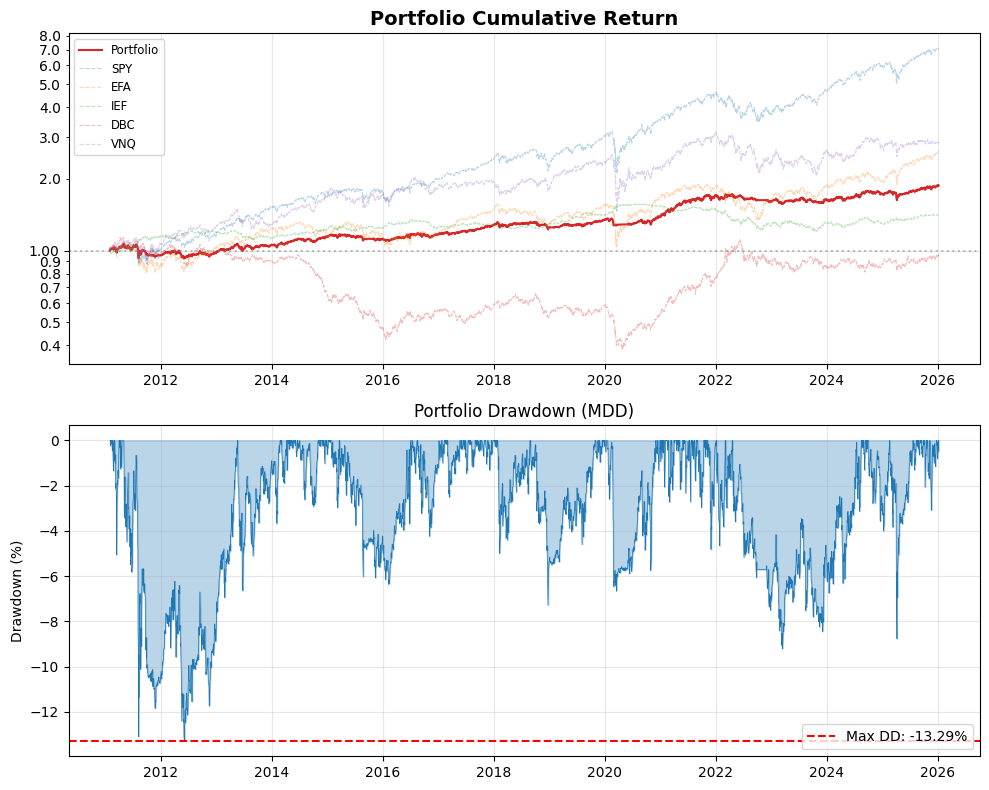

▶ 최종 수익률   : 87.74%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 4.32%
2. 안정성 (MDD)  : -13.29%
------------------------------
3. 연간 변동성   : 7.35%
4. 샤프 지수     : 0.3396


In [ ]:
gtaaDayReturn, gtaaCumReturn = cal_rebalancing_portfolio(close_data=gtaaDataWithCash, weight_df=gtaaWeightDf)
gtaaCagr, gtaaDD, gtaaMDD = evaluate_performance(gtaaDayReturn, gtaaCumReturn)

### GTAA 함수화

In [ ]:
import pandas as pd
import numpy as np

def getGTAAWeight(close_data, window=200):
    """
    GTAA 전략 비중 및 현금 컬럼이 추가된 가격 데이터를 반환하는 함수
    :param close_data: 종가 데이터
    :param window: 이동평균선 기간 (기본값: 200)
    :return: (weightDf, close_data_with_cash) 튜플 반환
    """

    # 1. gtaa 전략 종목 유니버스
    gtaaCol = ['SPY', 'EFA', "IEF", "DBC", "VNQ"]
    gtaaData = close_data[gtaaCol]

    # 2. 모멘텀 스코어 계산
    ma = gtaaData.rolling(window=window).mean()
    momentumScore = (gtaaData / ma) - 1
    momentumScore.dropna(inplace=True)

    # 3. 리밸런싱 일자
    gtaaRebalDate = get_rebalancing_dates(momentumScore)

    # 4. 비중(Weight) 계산
    weightDf = pd.DataFrame(np.where(momentumScore > 0, 0.2, 0), index=momentumScore.index, columns=gtaaCol)
    weightDf.index = pd.to_datetime(weightDf.index)
    weightDf = weightDf.loc[gtaaRebalDate]

    # 현금 비중 계산 (1 - 투자 비중 합계)
    weightDf['cash'] = 1 - weightDf.sum(axis=1)

    # 5. 백테스팅용 가격 데이터 생성 ('cash' 컬럼 추가)
    close_data_with_cash = close_data.copy()
    close_data_with_cash['cash'] = 1.0

    # 비중 데이터와 가격 데이터를 함께 반환합니다.
    return weightDf, close_data_with_cash

In [ ]:
weight_200 , price_data= getGTAAWeight(close_data, 200)
weight_200 , price_data

(            SPY  EFA  IEF  DBC  VNQ  cash
 Date                                     
 2009-10-30  0.2  0.2  0.2  0.2  0.2   0.0
 2009-11-30  0.2  0.2  0.2  0.2  0.2   0.0
 2009-12-31  0.2  0.2  0.0  0.2  0.2   0.2
 2010-01-29  0.2  0.2  0.2  0.0  0.2   0.2
 2010-02-26  0.2  0.2  0.2  0.2  0.2   0.0
 ...         ...  ...  ...  ...  ...   ...
 2025-09-30  0.2  0.2  0.2  0.2  0.2   0.0
 2025-10-31  0.2  0.2  0.2  0.2  0.2   0.0
 2025-11-28  0.2  0.2  0.2  0.2  0.2   0.0
 2025-12-31  0.2  0.2  0.2  0.2  0.2   0.0
 2026-01-07  0.2  0.2  0.2  0.2  0.2   0.0
 
 [196 rows x 6 columns],
                SPY     QQQ     IWM     DIA     VUG     IWO     VTV     IWN  \
 Date                                                                         
 2009-01-02   68.17   26.82   39.86   62.00   34.08   45.60   27.27   35.29   
 2009-01-05   68.09   26.81   40.01   61.66   34.16   45.97   27.13   35.38   
 2009-01-06   68.54   27.08   40.68   61.97   34.50   46.60   27.34   35.97   
 2009-01-07   66.49

In [ ]:
# 120일선(6개월) 사용 시
weight_120= getGTAAWeight(close_data, window=120)

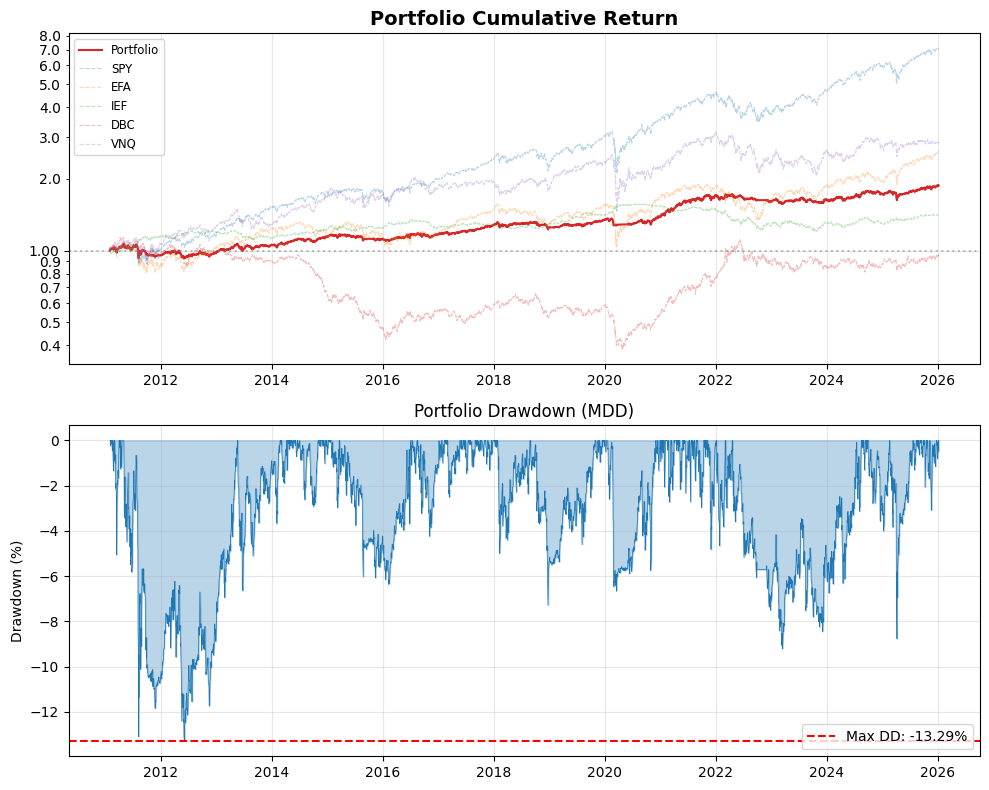

▶ 최종 수익률   : 87.74%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 4.32%
2. 안정성 (MDD)  : -13.29%
------------------------------
3. 연간 변동성   : 7.35%
4. 샤프 지수     : 0.3396


In [ ]:
weight_200 , price_data= getGTAAWeight(close_data, 200)
weight_200 = weight_200.loc['2011-01-01':]

gtaaDayReturn, gtaaCumReturn = cal_rebalancing_portfolio(close_data=price_data, period='month', weight_df=weight_200, enable_plot=True)
gtaaCagr, gtaaDD, gtaaMDD = evaluate_performance(gtaaDayReturn, gtaaCumReturn)

In [ ]:
close_data = pd.read_csv('/content/ETF 유니버스.csv', index_col=0, parse_dates=True)
close_data

,SPY,QQQ,IWM,DIA,VUG,IWO,VTV,IWN,USMV,QUAL,...,WGMI,BLOK,BIL,SGOV,NEAR,MINT,ICSH,JPST,PULS,VNQ.1
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,81.61,33.70,48.28,67.32,40.93,56.88,31.28,42.25,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.79
2005-01-04,80.61,33.08,47.24,66.68,40.56,55.44,31.00,41.48,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.45
2005-01-05,80.05,32.88,46.30,66.31,40.40,54.48,30.86,40.65,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.70
2005-01-06,80.46,32.71,46.54,66.51,40.39,54.74,31.01,40.76,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.87
2005-01-07,80.34,32.88,46.02,66.39,40.30,54.14,30.95,40.32,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,681.92,614.31,246.16,480.57,487.86,323.01,190.99,181.21,94.16,198.62,...,38.27,56.89,91.38,100.38,51.10,100.34,50.58,50.59,49.59,88.49
2026-01-02,683.17,613.12,248.78,483.63,486.20,327.12,192.81,182.87,93.65,199.19,...,42.05,59.24,91.42,100.41,51.12,100.37,50.58,50.62,49.62,88.52
2026-01-05,687.72,617.99,252.73,489.77,488.45,333.36,194.65,185.19,94.00,201.18,...,45.96,62.49,91.42,100.42,51.15,100.37,50.60,50.61,49.62,88.72


In [ ]:
faaCol = ['VTI', 'VEA', 'VWO', 'SHY', 'BND', 'DBC', 'VNQ']
faaData = close_data[faaCol]
faaData

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
Date,,,,,,,
2005-01-03,40.09,NaN,NaN,54.89,NaN,NaN,22.79
2005-01-04,39.56,NaN,NaN,54.77,NaN,NaN,22.45
2005-01-05,39.29,NaN,NaN,54.78,NaN,NaN,21.70
2005-01-06,39.47,NaN,NaN,54.81,NaN,NaN,21.87
2005-01-07,39.35,NaN,NaN,54.82,NaN,NaN,21.82
...,...,...,...,...,...,...,...
2025-12-31,335.27,62.47,53.76,82.82,74.07,22.36,88.49
2026-01-02,336.31,63.20,54.93,82.86,74.04,22.39,88.52
2026-01-05,338.84,63.95,55.29,82.89,74.18,22.81,88.72


In [ ]:
# 리밸런싱 날짜
faaRebalDate = get_rebalancing_dates(faaData)
faaRebalDate

,0
Date,
2005-01-31,2005-01-31
2005-02-28,2005-02-28
2005-03-31,2005-03-31
2005-04-30,2005-04-29
2005-05-31,2005-05-31
...,...
2025-09-30,2025-09-30
2025-10-31,2025-10-31
2025-11-30,2025-11-28


7개 자산의 모멘텀, 변동성, 상관성을 가중평균 평균하여 상위 3개 종목에 투자
단, 모멘텀 < 0인 종목의 비중은 현금에 투자

In [ ]:
# 리밸런싱 일자 가격 데이터
faaDataOnRebalDate = faaData.loc[faaRebalDate]
faaDataOnRebalDate

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
Date,,,,,,,
2005-01-31,39.37,NaN,NaN,54.86,NaN,NaN,21.08
2005-02-28,40.20,NaN,NaN,54.72,NaN,NaN,21.75
2005-03-31,39.44,NaN,13.48,54.73,NaN,NaN,21.38
2005-04-29,38.57,NaN,13.17,55.02,NaN,NaN,22.62
2005-05-31,40.07,NaN,13.55,55.23,NaN,NaN,23.41
...,...,...,...,...,...,...,...
2025-09-30,327.24,58.92,53.14,81.94,73.41,21.80,90.59
2025-10-31,334.47,59.97,53.91,82.22,73.85,22.14,88.37
2025-11-28,335.36,60.55,53.25,82.58,74.29,22.31,90.51


## 모멘텀 순위 계산

In [ ]:
# 4개월 모멘텀
momentum4 = faaDataOnRebalDate / faaDataOnRebalDate.shift(4)
momentum4.dropna(inplace=True)
momentum4

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
Date,,,,,,,
2007-11-30,1.024096,1.051953,1.135193,1.039242,1.050512,1.157499,1.025283
2007-12-31,1.002298,1.023230,1.124464,1.031535,1.043907,1.258745,0.908666
2008-01-31,0.905587,0.904611,0.931596,1.042918,1.050642,1.183968,0.867427
2008-02-29,0.867391,0.857432,0.848127,1.048628,1.042091,1.213161,0.822562
2008-03-31,0.900380,0.894571,0.892880,1.032596,1.026083,1.209180,0.967554
...,...,...,...,...,...,...,...
2025-09-30,1.138662,1.091718,1.162292,1.016751,1.035548,1.079208,1.043423
2025-10-31,1.106674,1.074924,1.117074,1.014310,1.026122,1.049289,1.010867
2025-11-28,1.084781,1.100509,1.095905,1.019632,1.034968,1.027164,1.034400


모멘텀이 높은 순으로 순위를 구해야한다.

pandas의 rank 함수를 사용

In [ ]:
df = pd.DataFrame({'A': [4, 8, 1, 8, 6], 'B': [5, 2, 11, 7, 3], 'C': [6, 10, 5, 1, 1]})
df

,A,B,C
0,4,5,6
1,8,2,10
2,1,11,5
3,8,7,1
4,6,3,1


In [ ]:
# 기본값으론 열방향 (axis=0) 을 따라서 값이 낮은 순서로 순위를 부여하고. 동점자는 평균값을 부여한다.
# 값이 높은 순서로 순위를 부여하려면? ascending=False
# 동점 처리는 어떻게 할까? method="first" 먼저 관측되는 순위를 높게
# 행방향으로 바꾸려면?, axis=1

df.rank(ascending=False, method="first", axis=1 )

,A,B,C
0,3.0,2.0,1.0
1,2.0,3.0,1.0
2,3.0,1.0,2.0
3,1.0,2.0,3.0
4,1.0,2.0,3.0


In [ ]:
# 모멘텀 순위
momentum4Score = momentum4.rank(method="first", axis=1, ascending=False)
momentum4Score

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
Date,,,,,,,
2007-11-30,7.0,3.0,2.0,5.0,4.0,1.0,6.0
2007-12-31,6.0,5.0,2.0,4.0,3.0,1.0,7.0
2008-01-31,5.0,6.0,4.0,3.0,2.0,1.0,7.0
2008-02-29,4.0,5.0,6.0,2.0,3.0,1.0,7.0
2008-03-31,5.0,6.0,7.0,2.0,3.0,1.0,4.0
...,...,...,...,...,...,...,...
2025-09-30,2.0,3.0,1.0,7.0,6.0,4.0,5.0
2025-10-31,2.0,3.0,1.0,6.0,5.0,4.0,7.0
2025-11-28,3.0,1.0,2.0,7.0,4.0,6.0,5.0


변동성 : 4개월 일일수익률의 표준편차(standard deviation) 순위 (낮을수록 좋음)

표준편차는 어떻게 구할까?
pandas의 std()함수를 사용하면 아주 쉽게 구할 수 있다.

In [ ]:
df

,A,B,C
0,4,5,6
1,8,2,10
2,1,11,5
3,8,7,1
4,6,3,1


In [ ]:
df.std()

,0
A,2.966479
B,3.577709
C,3.781534


In [ ]:
faaRebalDate

,0
Date,
2005-01-31,2005-01-31
2005-02-28,2005-02-28
2005-03-31,2005-03-31
2005-04-30,2005-04-29
2005-05-31,2005-05-31
...,...
2025-09-30,2025-09-30
2025-10-31,2025-10-31
2025-11-30,2025-11-28


In [ ]:
# 4개월 단위로 뽑아내기 위해 리밸런싱 일자 데이터 내림차순 정렬
reverseFaaRebalDate = faaRebalDate[::-1]
reverseFaaRebalDate

,0
Date,
2026-01-31,2026-01-07
2025-12-31,2025-12-31
2025-11-30,2025-11-28
2025-10-31,2025-10-31
2025-09-30,2025-09-30
...,...
2005-05-31,2005-05-31
2005-04-30,2005-04-29
2005-03-31,2005-03-31


In [ ]:
std4_list = [] # 빈 리스트 생성
dayReturn = calc_daily_return(faaData) # 일간 수익률

for index, date in enumerate(reverseFaaRebalDate) :
    # 4개월 데이터를 잡을 수 없으면 break
    if index >= len(reverseFaaRebalDate) - 4:
        break

    # 4개월 전 날짜
    before4month = reverseFaaRebalDate[index+4]

    # 4개월 일일수익률 표준편차
    std = dayReturn.loc[date:before4month:-1].std()
    std.name = date
    std4_list.append(std) # 리스트에 추가

std4 = pd.DataFrame(std4_list) # 리스트의 Series들을 DataFrame으로 변환
std4 = std4.sort_index(ascending=True)
std4

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
2005-05-31,0.007323,0.000000,0.010135,0.000767,0.000000,0.000000,0.009008
2005-06-30,0.006862,0.000000,0.010691,0.000787,0.000000,0.000000,0.008125
2005-07-29,0.006752,0.000000,0.010461,0.000829,0.000000,0.000000,0.007273
2005-08-31,0.005741,0.000000,0.010732,0.000853,0.000000,0.000000,0.009563
2005-09-30,0.005482,0.000000,0.009481,0.000833,0.000000,0.000000,0.009849
...,...,...,...,...,...,...,...
2025-09-30,0.005907,0.007000,0.006690,0.000922,0.002558,0.009437,0.008067
2025-10-31,0.006599,0.006940,0.007862,0.000890,0.002351,0.007669,0.008563
2025-11-28,0.007874,0.007237,0.008355,0.000856,0.002183,0.007863,0.008395
2025-12-31,0.007414,0.006800,0.007990,0.000647,0.001979,0.008164,0.007588


In [ ]:
std4Score = std4.rank(method="first", axis=1, ascending=True)
std4Score

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
2005-05-31,5.0,1.0,7.0,4.0,2.0,3.0,6.0
2005-06-30,5.0,1.0,7.0,4.0,2.0,3.0,6.0
2005-07-29,5.0,1.0,7.0,4.0,2.0,3.0,6.0
2005-08-31,5.0,1.0,7.0,4.0,2.0,3.0,6.0
2005-09-30,5.0,1.0,6.0,4.0,2.0,3.0,7.0
...,...,...,...,...,...,...,...
2025-09-30,3.0,5.0,4.0,1.0,2.0,7.0,6.0
2025-10-31,3.0,4.0,6.0,1.0,2.0,5.0,7.0
2025-11-28,5.0,3.0,6.0,1.0,2.0,4.0,7.0
2025-12-31,4.0,3.0,6.0,1.0,2.0,7.0,5.0


**상관성 : 4개월 하나의 자산과 다른 6개 자산간의 일일수익률의 상관성(correlation)의 합 순위 (낮을수록 좋음)**

* 상관성은 어떻게 구하나요?
    * pandas의 corr() 함수를 사용하면 피어슨 상관계수를 쉽게 계산 가능

In [ ]:
df

,A,B,C
0,4,5,6
1,8,2,10
2,1,11,5
3,8,7,1
4,6,3,1


In [ ]:
df.corr(method="pearson")

,A,B,C
A,1.000000,-0.711378,-0.026743
B,-0.711378,1.000000,-0.255003
C,-0.026743,-0.255003,1.000000


In [ ]:
import warnings
warnings.filterwarnings('ignore')
corr4_list = []
dayReturn = calc_daily_return(faaData) # 일간 수익률

for index, date in enumerate(reverseFaaRebalDate):
    # 4개월 데이터를 잡을 수 없으면 break
    if index >= len(reverseFaaRebalDate) - 4:
        break

    # 4개월 전 날짜
    before4month = reverseFaaRebalDate[index+4]

    # 4개월 상관성
    corr = abs(dayReturn.loc[date:before4month:-1].corr(method="pearson")).sum(axis=1)-1 # 자신에 대한 상관계수를 제거하기 위해 -1
    corr.name = date
    corr4_list.append(corr)

corr4 = pd.DataFrame(corr4_list)
corr4 = corr4.sort_index(ascending=True)
corr4

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
2005-05-31,1.462454,-1.000000,1.063941,0.451295,-1.000000,-1.000000,0.883962
2005-06-30,1.422356,-1.000000,1.123315,0.309026,-1.000000,-1.000000,0.909499
2005-07-29,1.418236,-1.000000,1.186329,0.329367,-1.000000,-1.000000,0.730559
2005-08-31,1.303310,-1.000000,1.064357,0.247312,-1.000000,-1.000000,1.040856
2005-09-30,1.271365,-1.000000,1.042008,0.150430,-1.000000,-1.000000,1.059918
...,...,...,...,...,...,...,...
2025-09-30,2.086481,2.854721,2.313373,1.899298,2.216148,1.780814,2.334245
2025-10-31,2.021535,2.518567,2.221735,1.745188,1.979848,1.137433,2.051347
2025-11-28,2.308319,2.605164,2.274407,1.635893,1.771562,1.444288,1.970589
2025-12-31,2.386410,2.717847,2.269266,1.516844,1.727964,1.474310,2.008321


In [ ]:
corr4Score = corr4.rank(method="first", axis=1, ascending=True)
corr4Score

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
2005-05-31,7.0,1.0,6.0,4.0,2.0,3.0,5.0
2005-06-30,7.0,1.0,6.0,4.0,2.0,3.0,5.0
2005-07-29,7.0,1.0,6.0,4.0,2.0,3.0,5.0
2005-08-31,7.0,1.0,6.0,4.0,2.0,3.0,5.0
2005-09-30,7.0,1.0,5.0,4.0,2.0,3.0,6.0
...,...,...,...,...,...,...,...
2025-09-30,3.0,7.0,5.0,2.0,4.0,1.0,6.0
2025-10-31,4.0,7.0,6.0,2.0,3.0,1.0,5.0
2025-11-28,6.0,7.0,5.0,2.0,3.0,1.0,4.0
2025-12-31,6.0,7.0,5.0,2.0,3.0,1.0,4.0


**가중평균 : (모멘텀 * 1) + (변동성 * 0.5) + (상관성 * 0.5) 값이 낮은 순서대로 순위를 매김**

In [ ]:
# 가중평균
weightedAverage = (momentum4Score + 0.5 * (std4Score + corr4Score))
weightedAverage.dropna(inplace=True)
weightedAverage


,VTI,VEA,VWO,SHY,BND,DBC,VNQ
2007-11-30,12.5,8.5,8.0,7.5,6.0,3.0,10.5
2007-12-31,11.0,10.0,8.5,6.5,5.0,3.5,11.5
2008-01-31,10.5,11.0,10.5,5.5,4.5,3.0,11.0
2008-02-29,9.5,10.0,12.0,4.5,5.5,3.0,11.5
2008-03-31,10.0,10.5,13.0,4.5,5.0,4.0,9.0
...,...,...,...,...,...,...,...
2025-09-30,5.0,9.0,5.5,8.5,9.0,8.0,11.0
2025-10-31,5.5,8.5,7.0,7.5,7.5,7.0,13.0
2025-11-28,8.5,6.0,7.5,8.5,6.5,8.5,10.5
2025-12-31,8.0,6.0,7.5,7.5,7.5,8.0,11.5


In [ ]:
totalScore = weightedAverage.rank(method="first", axis=1, ascending=True)
totalScore

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
2007-11-30,7.0,5.0,4.0,3.0,2.0,1.0,6.0
2007-12-31,6.0,5.0,4.0,3.0,2.0,1.0,7.0
2008-01-31,4.0,6.0,5.0,3.0,2.0,1.0,7.0
2008-02-29,4.0,5.0,7.0,2.0,3.0,1.0,6.0
2008-03-31,5.0,6.0,7.0,2.0,3.0,1.0,4.0
...,...,...,...,...,...,...,...
2025-09-30,1.0,5.0,2.0,4.0,6.0,3.0,7.0
2025-10-31,1.0,6.0,2.0,4.0,5.0,3.0,7.0
2025-11-28,4.0,1.0,3.0,5.0,2.0,6.0,7.0
2025-12-31,5.0,1.0,2.0,3.0,4.0,6.0,7.0


In [ ]:
# 모멘텀 1 미만에 대해서는 현금투자,
# 랭킹에서 상위 3가지 뽑아 내는 방법

weight = (totalScore <= 3) & (momentum4 >= 1) # 가중평균 3위 내, 모멘텀 1이상
weight

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
2007-11-30,False,False,False,True,True,True,False
2007-12-31,False,False,False,True,True,True,False
2008-01-31,False,False,False,True,True,True,False
2008-02-29,False,False,False,True,True,True,False
2008-03-31,False,False,False,True,True,True,False
...,...,...,...,...,...,...,...
2025-09-30,True,False,True,False,False,True,False
2025-10-31,True,False,True,False,False,True,False
2025-11-28,False,True,True,False,True,False,False
2025-12-31,False,True,True,True,False,False,False


In [ ]:
faaWeight = weight.replace(True, 1/3).replace(False, 0)
faaWeight

,VTI,VEA,VWO,SHY,BND,DBC,VNQ
2007-11-30,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,0.0
2007-12-31,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,0.0
2008-01-31,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,0.0
2008-02-29,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,0.0
2008-03-31,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,0.0
...,...,...,...,...,...,...,...
2025-09-30,0.333333,0.000000,0.333333,0.000000,0.000000,0.333333,0.0
2025-10-31,0.333333,0.000000,0.333333,0.000000,0.000000,0.333333,0.0
2025-11-28,0.000000,0.333333,0.333333,0.000000,0.333333,0.000000,0.0
2025-12-31,0.000000,0.333333,0.333333,0.333333,0.000000,0.000000,0.0


In [ ]:
faaWeight['cash'] = 1 - faaWeight.sum(axis=1)
faaWeight = faaWeight.loc['2010-12-31':]
faaWeight

,VTI,VEA,VWO,SHY,BND,DBC,VNQ,cash
2010-12-31,0.333333,0.000000,0.333333,0.000000,0.000000,0.333333,0.000000,0.0
2011-01-31,0.333333,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.0
2011-02-28,0.333333,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.0
2011-03-31,0.333333,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.0
2011-04-29,0.333333,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,0.0
...,...,...,...,...,...,...,...,...
2025-09-30,0.333333,0.000000,0.333333,0.000000,0.000000,0.333333,0.000000,0.0
2025-10-31,0.333333,0.000000,0.333333,0.000000,0.000000,0.333333,0.000000,0.0
2025-11-28,0.000000,0.333333,0.333333,0.000000,0.333333,0.000000,0.000000,0.0
2025-12-31,0.000000,0.333333,0.333333,0.333333,0.000000,0.000000,0.000000,0.0


In [ ]:
# 현금 컬럼 추가
faaDataWithCash = faaData.copy()
faaDataWithCash.loc[:, 'cash'] = 1
faaDataWithCash

,VTI,VEA,VWO,SHY,BND,DBC,VNQ,cash
Date,,,,,,,,
2005-01-03,40.09,NaN,NaN,54.89,NaN,NaN,22.79,1
2005-01-04,39.56,NaN,NaN,54.77,NaN,NaN,22.45,1
2005-01-05,39.29,NaN,NaN,54.78,NaN,NaN,21.70,1
2005-01-06,39.47,NaN,NaN,54.81,NaN,NaN,21.87,1
2005-01-07,39.35,NaN,NaN,54.82,NaN,NaN,21.82,1
...,...,...,...,...,...,...,...,...
2025-12-31,335.27,62.47,53.76,82.82,74.07,22.36,88.49,1
2026-01-02,336.31,63.20,54.93,82.86,74.04,22.39,88.52,1
2026-01-05,338.84,63.95,55.29,82.89,74.18,22.81,88.72,1


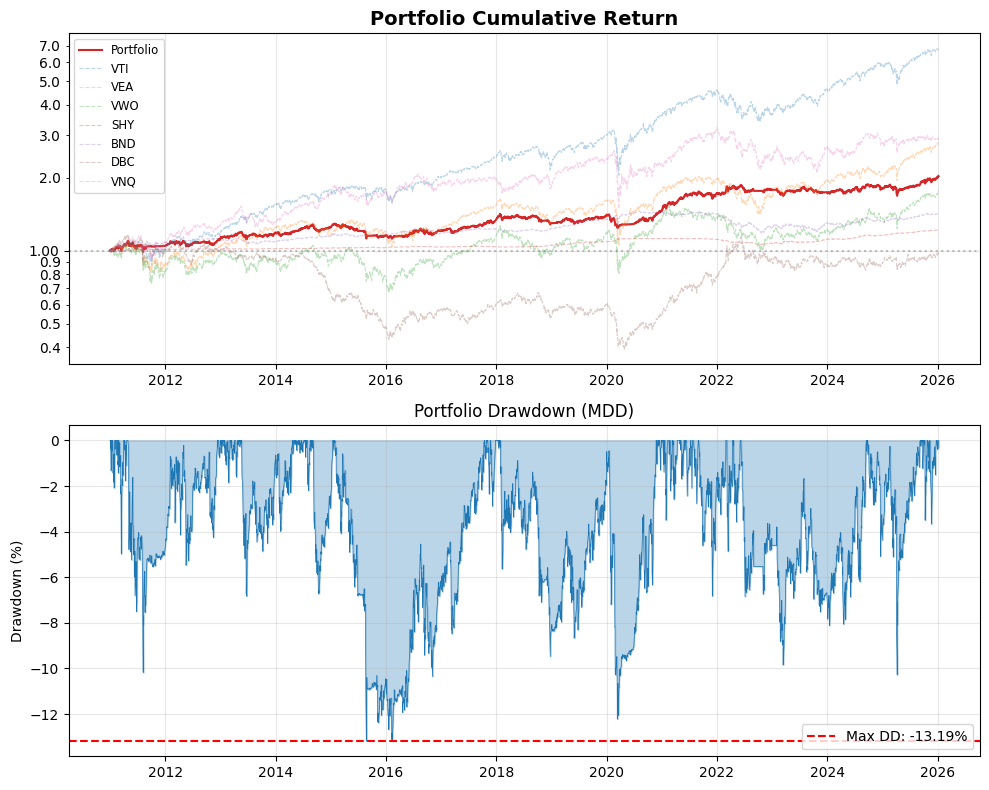

▶ 최종 수익률   : 103.14%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 4.84%
2. 안정성 (MDD)  : -13.19%
------------------------------
3. 연간 변동성   : 8.12%
4. 샤프 지수     : 0.3768


In [ ]:
faaDayReturn, faaCumReturn = cal_rebalancing_portfolio(close_data=faaDataWithCash.loc[faaWeight.index[0]:], weight_df=faaWeight)
faaCagr, faaDD, faaMDD = evaluate_performance(faaDayReturn, faaCumReturn)

# VAA

공격자산, 수비자산 설정.
공격자산 : SPY(미국주식), VEA(선진국 주식), EEM(이머징 주식), AGG(미국 총채권)

수비자산 : LQD(미국 회사채), SHY(미국 단기국채), IEF(미국 중기국채)

모멘텀 스코어를 구한다.
모멘텀 = (현재 주가 / n개월 전 주가) - 1

(최근 1개월 수익률x12) + (최근 3개월 수익률x4) + (최근 6개월 수익률x2) + (최근 12개월 수익률x1)

공격자산 4개 모멘텀 스코어가 전부 0 이상일 경우 가장 모멘텀스코어가 높은 공격자산에 올인

공격자산 중 하나라도 모멘텀스코어가 0 이하일 경우 가장 모멘텀스코어가 높은 수비자산에 올인

In [ ]:
close_data = pd.read_csv('/content/ETF 유니버스.csv', index_col=0, parse_dates=True)

In [ ]:
vaaCol = ['SPY', "VEA", "EEM", "AGG", "LQD", "SHY", "IEF"]
vaaAttack = ['SPY', "VEA", "EEM", "AGG"]
vaaDefense = ["LQD", "SHY", "IEF"]
vaaData = close_data[vaaCol]
vaaData

,SPY,VEA,EEM,AGG,LQD,SHY,IEF
Date,,,,,,,
2005-01-03,81.61,NaN,14.56,52.61,48.24,54.89,48.71
2005-01-04,80.61,NaN,14.11,52.56,47.97,54.77,48.41
2005-01-05,80.05,NaN,13.94,52.54,48.01,54.78,48.49
2005-01-06,80.46,NaN,13.93,52.57,48.04,54.81,48.53
2005-01-07,80.34,NaN,13.96,52.56,48.02,54.82,48.49
...,...,...,...,...,...,...,...
2025-12-31,681.92,62.47,54.71,99.88,110.19,82.82,96.16
2026-01-02,683.17,63.20,56.24,99.85,110.16,82.86,96.08
2026-01-05,687.72,63.95,56.86,100.04,110.47,82.89,96.37


In [ ]:
# 모멘텀 스코어를 구하기
# (최근 1개월 수익률x12) + (최근 3개월 수익률x4) + (최근 6개월 수익률x2) + (최근 12개월 수익률x1)


rebalDate = get_rebalancing_dates(vaaData) # 리밸런싱 매월 말 날짜
vaaDataOnRebalDate = vaaData.loc[rebalDate] # 매월 말 가격 데이터

momentum1 = vaaDataOnRebalDate / vaaDataOnRebalDate.shift(1) -1 # 1개월 모멘텀
momentum3 = vaaDataOnRebalDate / vaaDataOnRebalDate.shift(3) - 1 # 3개월 모멘텀
momentum6 = vaaDataOnRebalDate / vaaDataOnRebalDate.shift(6) -1 # 6개월 모멘텀
momentum12 = vaaDataOnRebalDate / vaaDataOnRebalDate.shift(12) -1 # 12개월 모멘텀

momentumScore = 12*momentum1 + 4*momentum3 + 2*momentum6 + momentum12 # 모멘텀 스코어
momentumScore.dropna(inplace=True)
momentumScore

,SPY,VEA,EEM,AGG,LQD,SHY,IEF
Date,,,,,,,
2008-07-31,-0.668410,-1.092870,-1.237837,0.053884,-0.104137,0.149504,0.208569
2008-08-29,-0.291258,-1.431796,-1.884454,0.188021,-0.044667,0.168844,0.436229
2008-09-30,-1.930757,-2.806845,-3.492487,-0.237912,-2.046651,0.238174,0.153098
2008-10-31,-3.855952,-5.016296,-6.172251,-0.493059,-1.153664,0.353915,0.009208
2008-11-28,-3.104140,-3.539316,-4.501242,0.327198,-0.290723,0.400779,1.526909
...,...,...,...,...,...,...,...
2025-09-30,1.323043,1.088767,1.943283,0.314944,0.468609,0.159347,0.228793
2025-10-31,1.302294,1.167333,1.811133,0.325940,0.315151,0.184558,0.327036
2025-11-28,0.753247,0.839095,0.842269,0.320205,0.411999,0.193552,0.379435


In [ ]:
# 공격자산 4개 모멘텀 스코어가 전부 0 초과일 경우 가장 모멘텀스코어가 높은 공격자산에 몰빵
# 공격자산 중 하나라도 모멘텀스코어가 0 이하일 경우 가장 모멘텀스코어가 높은 수비자산에 몰빵

momentumScore[vaaAttack] > 0

,SPY,VEA,EEM,AGG
Date,,,,
2008-07-31,False,False,False,True
2008-08-29,False,False,False,True
2008-09-30,False,False,False,False
2008-10-31,False,False,False,False
2008-11-28,False,False,False,True
...,...,...,...,...
2025-09-30,True,True,True,True
2025-10-31,True,True,True,True
2025-11-28,True,True,True,True


In [ ]:
isAttack = (momentumScore[vaaAttack] > 0).all(axis=1)
isAttack

,0
Date,
2008-07-31,False
2008-08-29,False
2008-09-30,False
2008-10-31,False
2008-11-28,False
...,...
2025-09-30,True
2025-10-31,True
2025-11-28,True


In [ ]:
import pandas as pd

s = pd.Series({'철수': 80, '영희': 95, '민수': 70})

In [ ]:
s.index

Index(['철수', '영희', '민수'], dtype='object')

In [ ]:
s.idxmax()

'영희'

## VAA 투자 비중 계산

In [ ]:
momentumScore

,SPY,VEA,EEM,AGG,LQD,SHY,IEF
Date,,,,,,,
2008-07-31,-0.668410,-1.092870,-1.237837,0.053884,-0.104137,0.149504,0.208569
2008-08-29,-0.291258,-1.431796,-1.884454,0.188021,-0.044667,0.168844,0.436229
2008-09-30,-1.930757,-2.806845,-3.492487,-0.237912,-2.046651,0.238174,0.153098
2008-10-31,-3.855952,-5.016296,-6.172251,-0.493059,-1.153664,0.353915,0.009208
2008-11-28,-3.104140,-3.539316,-4.501242,0.327198,-0.290723,0.400779,1.526909
...,...,...,...,...,...,...,...
2025-09-30,1.323043,1.088767,1.943283,0.314944,0.468609,0.159347,0.228793
2025-10-31,1.302294,1.167333,1.811133,0.325940,0.315151,0.184558,0.327036
2025-11-28,0.753247,0.839095,0.842269,0.320205,0.411999,0.193552,0.379435


In [ ]:
def getVAAWegiht(row):
    vaaAttack = ['SPY', "VEA", "EEM", "AGG"]
    vaaDefense = ["LQD", "SHY", "IEF"]

#     print(row)
#     print(row.name) # series row의 name, 날짜
#     print(row.index) # series row의 index, 종목 ticker

    # 공격자산을 선택하는 경우,
    if isAttack[row.name]:
        # 공격자산 중 가장 모멘텀 스코어가 높은 종목에 몰빵
        result = pd.Series(row.index == row[vaaAttack].idxmax(), index=row.index, name=row.name).astype(int)
        return result

    # 수비자산을 선택하는 경우,
    # 수비자산 중 가장 모멘텀스코어가 높은 종목에 몰빵
    result = pd.Series(row.index == row[vaaDefense].idxmax(), index=row.index, name=row.name).astype(int)
    return result

vaaWeight = momentumScore.apply(getVAAWegiht, axis=1)
vaaWeight = vaaWeight.loc["2010-12-31":]
vaaWeight

,SPY,VEA,EEM,AGG,LQD,SHY,IEF
Date,,,,,,,
2010-12-31,0,0,0,0,0,1,0
2011-01-31,0,0,0,0,0,1,0
2011-02-28,0,1,0,0,0,0,0
2011-03-31,0,0,0,0,1,0,0
2011-04-29,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...
2025-09-30,0,0,1,0,0,0,0
2025-10-31,0,0,1,0,0,0,0
2025-11-28,0,0,1,0,0,0,0


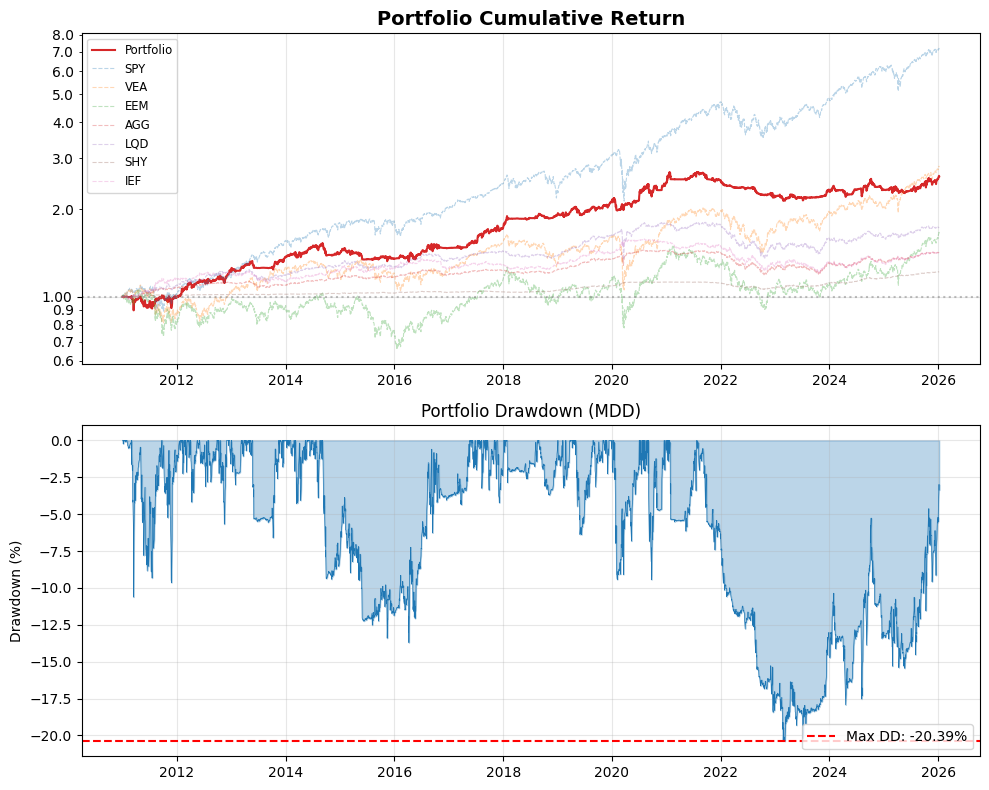

▶ 최종 수익률   : 160.17%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.59%
2. 안정성 (MDD)  : -20.39%
------------------------------
3. 연간 변동성   : 10.17%
4. 샤프 지수     : 0.4817


In [ ]:
vaaDayReturn, vaaCumReturn = cal_rebalancing_portfolio(vaaData.loc[vaaWeight.index[0]:], weight_df=vaaWeight)
vaaCagr, vaaDD, vaaMDD = evaluate_performance(vaaDayReturn, vaaCumReturn)

## VAA 함수화

In [ ]:
def getVAAWeight(closeDataSet):
    vaaCol = ['SPY', "VEA", "EEM", "AGG", "LQD", "SHY", "IEF"]
    vaaAttack = ['SPY', "VEA", "EEM", "AGG"]
    vaaDefense = ["LQD", "SHY", "IEF"]
    vaaData = closeDataSet[vaaCol]

    # 모멘텀 스코어를 구하기
    # (최근 1개월 수익률x12) + (최근 3개월 수익률x4) + (최근 6개월 수익률x2) + (최근 12개월 수익률x1)
    rebalDate = get_rebalancing_dates(vaaData)
    vaaDataOnRebalDate = vaaData.loc[rebalDate]

    momentum1 = vaaDataOnRebalDate / vaaDataOnRebalDate.shift(1) -1
    momentum3 = vaaDataOnRebalDate / vaaDataOnRebalDate.shift(3) - 1
    momentum6 = vaaDataOnRebalDate / vaaDataOnRebalDate.shift(6) -1
    momentum12 = vaaDataOnRebalDate / vaaDataOnRebalDate.shift(12) -1

    momentumScore = 12*momentum1 + 4*momentum3 + 2*momentum6 + momentum12
    momentumScore.dropna(inplace=True)

    # 공격자산 4개 모멘텀 스코어가 전부 0 초과일 경우 가장 모멘텀스코어가 높은 공격자산에 몰빵
    # 공격자산 중 하나라도 모멘텀스코어가 0 이하일 경우 가장 모멘텀스코어가 높은 수비자산에 몰빵
    isAttack = (momentumScore[vaaAttack] > 0).all(axis=1)
    vaaWeight = momentumScore.apply(applyGetVAAWegiht, axis=1, args=(isAttack,))

    return vaaWeight

def applyGetVAAWegiht(row, isAttack):
    vaaAttack = ['SPY', "VEA", "EEM", "AGG"]
    vaaDefense = ["LQD", "SHY", "IEF"]

    if isAttack[row.name]:
        # 공격자산 중 가장 모멘텀 스코어가 높은 종목에 몰빵
        return pd.Series(row.index == row[vaaAttack].idxmax(), index=row.index, name=row.name).astype(int)

    # 수비자산 중 가장 모멘텀스코어가 높은 종목에 몰빵
    return pd.Series(row.index == row[vaaDefense].idxmax(), index=row.index, name=row.name).astype(int)

In [ ]:
getVAAWeight(close_data)

,SPY,VEA,EEM,AGG,LQD,SHY,IEF
Date,,,,,,,
2008-07-31,0,0,0,0,0,0,1
2008-08-29,0,0,0,0,0,0,1
2008-09-30,0,0,0,0,0,1,0
2008-10-31,0,0,0,0,0,1,0
2008-11-28,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...
2025-09-30,0,0,1,0,0,0,0
2025-10-31,0,0,1,0,0,0,0
2025-11-28,0,0,1,0,0,0,0


In [ ]:
vaaWeightDf = getVAAWeight(close_data).loc["2010-12-31":]
vaaDayReturn, vaaCumReturn = cal_rebalancing_portfolio(close_data=close_data, weight_df=vaaWeightDf, enable_plot=False)
vaaCagr, vaaDD, vaaMDD = evaluate_performance(vaaDayReturn, vaaCumReturn)

▶ 최종 수익률   : 160.17%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.59%
2. 안정성 (MDD)  : -20.39%
------------------------------
3. 연간 변동성   : 10.17%
4. 샤프 지수     : 0.4817


# DAA

공격자산, 수비자산 설정
공격자산 : SPY(S&P500), IWM(러셀 2000), QQQ(나스닥), VGK(유럽 주식), EWJ(일본 주식), VWO(개발도상국 주식), VNQ(미국 리츠), GSG(원자재), GLD(금), TLT(미국 장기채), HYG(하이일드 채권), LQD(회사채)

수비자산 : SHY(미국 단기국채), IEF(미국 중기국채), UST(미국 중기채 레버리지)

카나리아 자산 설정
카나리아 자산 : VWO(개발도상국 주식), BND(미국 총채권)

모멘텀 스코어 계산
(최근 1개월 수익률x12) + (최근 3개월 수익률x4) + (최근 6개월 수익률x2) + (최근 12개월 수익률x1)

카나리아 자산 모멘텀 스코어가 모두 0 초과일 때 공격 자산 중 모멘텀 스코어가 가장 큰 2개 자산을 보유

카나리아 자산 중 하나의 자산만 모멘텀 스코어0 초과일 때 모멘텀 스코어가 가장 큰 공격 자산 1개와 방어자산 1개

카나리아 자산 모두 모멘텀스코어가 0 이하라면 수비 자산 중 모멘텀 스코어가 가장 큰 자산에 몰빵

In [ ]:
close_data = pd.read_csv('/content/ETF 유니버스.csv', index_col=0, parse_dates=True)

In [ ]:
daaCol = ['SPY', "IWM", "QQQ", "VGK", "EWJ", "VWO", "VNQ", "GSG", "GLD", "TLT","UST", "HYG", "LQD", "SHY", "IEF","BND"]
daaAttack = ['SPY', "IWM", "QQQ", "VGK", "EWJ", "VWO", "VNQ", "GSG", "GLD", "HYG", "LQD"]
daaDefense = [ "SHY", "IEF", "UST"]
daaCanary = ["VWO", "BND"]
daaData = close_data[daaCol]
daaData

,SPY,IWM,QQQ,VGK,EWJ,VWO,VNQ,GSG,GLD,TLT,UST,HYG,LQD,SHY,IEF,BND
Date,,,,,,,,,,,,,,,,
2005-01-03,81.61,48.28,33.70,NaN,30.64,NaN,22.79,NaN,43.02,45.06,NaN,NaN,48.24,54.89,48.71,NaN
2005-01-04,80.61,47.24,33.08,NaN,30.13,NaN,22.45,NaN,42.74,44.59,NaN,NaN,47.97,54.77,48.41,NaN
2005-01-05,80.05,46.30,32.88,NaN,30.11,NaN,21.70,NaN,42.67,44.83,NaN,NaN,48.01,54.78,48.49,NaN
2005-01-06,80.46,46.54,32.71,NaN,30.11,NaN,21.87,NaN,42.15,44.86,NaN,NaN,48.04,54.81,48.53,NaN
2005-01-07,80.34,46.02,32.88,NaN,29.93,NaN,21.82,NaN,41.84,44.96,NaN,NaN,48.02,54.82,48.49,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,681.92,246.16,614.31,83.61,80.74,53.76,88.49,23.06,396.31,87.16,43.66,80.63,110.19,82.82,96.16,74.07
2026-01-02,683.17,248.78,613.12,84.56,81.33,54.93,88.52,23.07,398.28,87.03,43.57,80.67,110.16,82.86,96.08,74.04
2026-01-05,687.72,252.73,617.99,85.23,83.13,55.29,88.72,23.49,408.76,87.46,43.88,80.88,110.47,82.89,96.37,74.18


모멘텀 스코어 계산

(최근 1개월 수익률x12) + (최근 3개월 수익률x4) + (최근 6개월 수익률x2) + (최근 12개월 수익률x1)

In [ ]:
rebalDate = get_rebalancing_dates(daaData)
rebalDate

,0
Date,
2005-01-31,2005-01-31
2005-02-28,2005-02-28
2005-03-31,2005-03-31
2005-04-30,2005-04-29
2005-05-31,2005-05-31
...,...
2025-09-30,2025-09-30
2025-10-31,2025-10-31
2025-11-30,2025-11-28


In [ ]:
rebalDate = get_rebalancing_dates(daaData)
daaDataOnRebalDate = daaData.loc[rebalDate]

momentum1 = daaDataOnRebalDate / daaDataOnRebalDate.shift(1) -1
momentum3 = daaDataOnRebalDate / daaDataOnRebalDate.shift(3) - 1
momentum6 = daaDataOnRebalDate / daaDataOnRebalDate.shift(6) -1
momentum12 = daaDataOnRebalDate / daaDataOnRebalDate.shift(12) -1

momentumScore = 12*momentum1 + 4*momentum3 + 2*momentum6 + momentum12
momentumScore.dropna(inplace=True)
momentumScore

,SPY,IWM,QQQ,VGK,EWJ,VWO,VNQ,GSG,GLD,TLT,UST,HYG,LQD,SHY,IEF,BND
Date,,,,,,,,,,,,,,,,
2011-02-28,1.717292,2.289284,1.795624,1.772503,1.829757,0.654942,1.903948,1.699042,1.299177,-0.219973,-0.582427,0.773872,0.209118,-0.009796,-0.198992,0.037452
2011-03-31,0.738596,1.381715,0.721151,0.471066,-1.371421,1.094977,0.592580,1.488007,0.695207,-0.202104,-0.062807,0.395478,-0.010191,-0.012262,-0.057210,0.017760
2011-04-29,1.102730,1.452971,1.053677,2.000876,0.243954,1.179498,1.579046,1.674473,2.385025,0.414123,0.455602,0.567206,0.514670,0.094373,0.295948,0.294026
2011-05-31,0.493380,0.563599,0.441289,0.658426,-0.625698,0.378564,1.083786,-0.176231,0.601863,0.699470,1.096303,0.429762,0.463752,0.103578,0.548201,0.334327
2011-06-30,0.221313,0.137808,0.188044,0.445617,0.452369,0.173775,0.293020,-0.833622,0.188532,-0.140793,0.407098,0.226066,0.159229,0.061268,0.195311,0.133014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30,1.323043,1.425981,1.806778,0.832273,1.082081,1.671089,0.186173,0.385562,3.005332,0.485913,0.278350,0.382685,0.468609,0.159347,0.228793,0.306243
2025-10-31,1.302294,1.398528,1.991528,0.808783,1.629207,1.281131,-0.210880,0.524091,2.163120,0.451118,0.460508,0.276338,0.315151,0.184558,0.327036,0.317395
2025-11-28,0.753247,0.845064,0.772819,0.787133,0.656912,0.650260,0.341882,0.418007,2.656642,0.384745,0.600524,0.321514,0.411999,0.193552,0.379435,0.315974


## DAA 투자비중 계산

In [ ]:
isAttack = (momentumScore[daaCanary] > 0).sum(axis=1)
isAttack

,0
Date,
2011-02-28,2
2011-03-31,2
2011-04-29,2
2011-05-31,2
2011-06-30,2
...,...
2025-09-30,2
2025-10-31,2
2025-11-28,2


In [ ]:
s = pd.Series({'철수': 70, '영희': 95, '민수': 80, '지수': 75, '동현': 100})

In [ ]:
s.nlargest(n=2)

,0
동현,100
영희,95


In [ ]:
s = pd.Series([1, 10, 5, 12, 7])

In [ ]:
s.isin([10, 12])

,0
0,False
1,True
2,False
3,True
4,False


In [ ]:
def applyGetDAAWeight(row):
    if isAttack[row.name] == 2:
        # 카나리아 자산 모멘텀 스코어가 모두 0 초과일 때 공격 자산 중 모멘텀 스코어가 가장 큰 2개 자산을 보유
        top2 = row[daaAttack].nlargest(n=2).index
        result = pd.Series(row.index.isin(top2), index=row.index, name=row.name).astype(int).replace(1, 0.5)
        return result

    if isAttack[row.name] == 1:
        # 카나리아 자산 중 하나의 자산만 모멘텀 스코어0 초과일 때 모멘텀 스코어가 가장 큰 공격 자산 1개와 방어자산 1개
        topAttack = row[daaAttack].idxmax()
        topDefense = row[daaDefense].idxmax()
        result = pd.Series(row.index.isin([topAttack, topDefense]), index=row.index, name=row.name).astype(int).replace(1, 0.5)
        return result

    # 카나리아 자산 모두 모멘텀스코어가 0 이하라면 수비 자산 중 모멘텀 스코어가 가장 큰 자산에 몰빵
    return pd.Series(row.index == row[daaDefense].idxmax(), index=row.index, name=row.name).astype(int)


daaWeight = momentumScore.apply(applyGetDAAWeight, axis=1)
daaWeight = daaWeight.loc['2010-12-31':]
daaWeight

,SPY,IWM,QQQ,VGK,EWJ,VWO,VNQ,GSG,GLD,TLT,UST,HYG,LQD,SHY,IEF,BND
Date,,,,,,,,,,,,,,,,
2011-02-28,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-03-31,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-04-29,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-05-31,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-06-30,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-31,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-11-28,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0


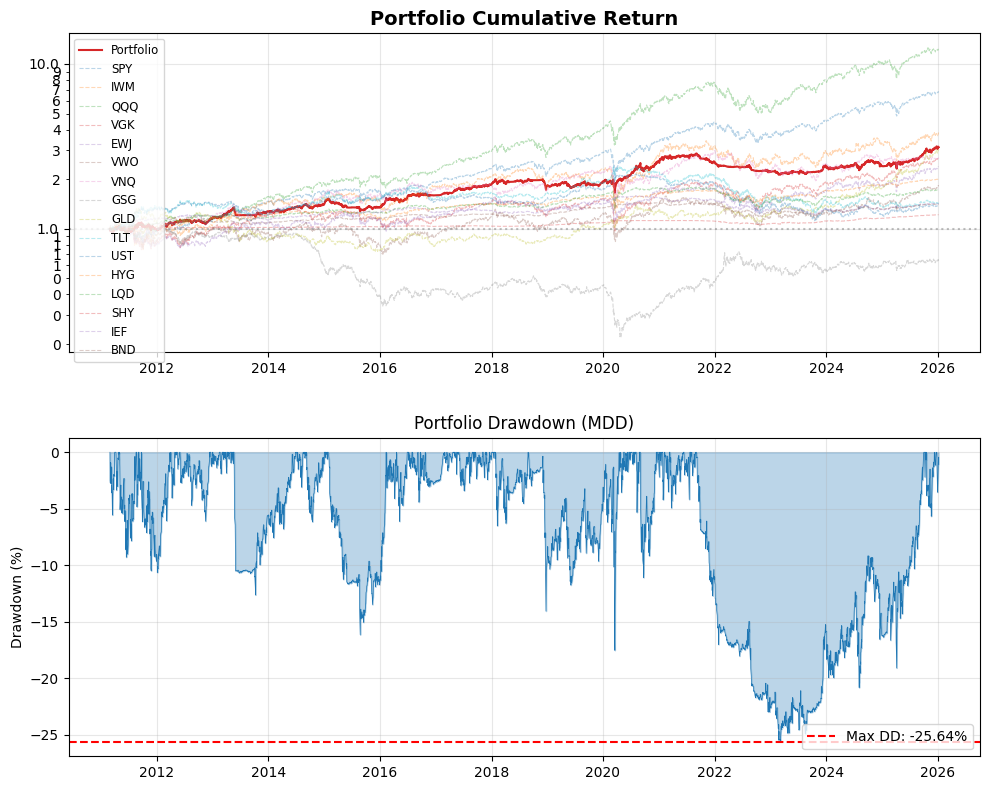

▶ 최종 수익률   : 213.07%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 8.00%
2. 안정성 (MDD)  : -25.64%
------------------------------
3. 연간 변동성   : 12.08%
4. 샤프 지수     : 0.5319


In [ ]:

daaDayReturn, daaCumReturn = cal_rebalancing_portfolio(close_data=daaData.loc[daaWeight.index[0]:], weight_df=daaWeight, enable_plot=True)
daaCagr, daaDD, daaMDD = evaluate_performance(daaDayReturn, daaCumReturn)

## DAA 함수화

In [ ]:
def getDAAWeight(closeDataSet):

    daaCol = ['SPY', "IWM", "QQQ", "VGK", "EWJ", "VWO", "VNQ", "GSG", "GLD", "TLT","UST", "HYG", "LQD", "SHY", "IEF","BND"]
    daaAttack = ['SPY', "IWM", "QQQ", "VGK", "EWJ", "VWO", "VNQ", "GSG", "GLD", "HYG", "LQD"]

    daaDefense = [ "SHY", "IEF", "UST"]
    daaCanary = ["VWO", "BND"]

    daaData = closeDataSet[daaCol].copy()
    daaData.dropna(inplace=True)

    # 모멘텀 스코어 계산
    rebalDate = get_rebalancing_dates(daaData)
    daaDataOnRebalDate = daaData.loc[rebalDate]

    momentum1 = daaDataOnRebalDate / daaDataOnRebalDate.shift(1) -1
    momentum3 = daaDataOnRebalDate / daaDataOnRebalDate.shift(3) - 1
    momentum6 = daaDataOnRebalDate / daaDataOnRebalDate.shift(6) -1
    momentum12 = daaDataOnRebalDate / daaDataOnRebalDate.shift(12) -1

    momentumScore = 12*momentum1 + 4*momentum3 + 2*momentum6 + momentum12
    momentumScore.dropna(inplace=True)

    # 카나리아 자산 모멘텀 스코어가 모두 0 초과일 때 공격 자산 중 모멘텀 스코어가 가장 큰 2개 자산을 보유
    # 카나리아 자산 중 하나의 자산만 모멘텀 스코어0 초과일 때 모멘텀 스코어가 가장 큰 공격 자산 1개와 방어자산 1개
    # 카나리아 자산 모두 모멘텀스코어가 0 이하라면 수비 자산 중 모멘텀 스코어가 가장 큰 자산에 몰빵
    isAttack = (momentumScore[daaCanary] > 0).sum(axis=1)
    daaWeight = momentumScore.apply(applyGetDAAWeight, axis=1, args=(isAttack,))
    return daaWeight

def applyGetDAAWeight(row, isAttack):
    daaCol = ['SPY', "IWM", "QQQ", "VGK", "EWJ", "VWO", "VNQ", "GSG", "GLD", "TLT", "HYG", "LQD", "SHY", "IEF","BND"]
    daaAttack = ['SPY', "IWM", "QQQ", "VGK", "EWJ", "VWO", "VNQ", "GSG", "GLD", "HYG", "LQD"]

    daaDefense = [ "SHY", "IEF", "UST"]
    daaCanary = ["VWO", "BND"]

    if isAttack[row.name] == 2:
        # 카나리아 자산 모멘텀 스코어가 모두 0 초과일 때 공격 자산 중 모멘텀 스코어가 가장 큰 2개 자산을 보유
        top2 = row[daaAttack].nlargest(n=2).index
        result = pd.Series(row.index.isin(top2), index=row.index, name=row.name).astype(int).replace(1, 0.5)
        return result

    if isAttack[row.name] == 1:
        # 카나리아 자산 중 하나의 자산만 모멘텀 스코어0 초과일 때 모멘텀 스코어가 가장 큰 공격 자산 1개와 방어자산 1개
        topAttack = row[daaAttack].idxmax()
        topDefense = row[daaDefense].idxmax()
        result = pd.Series(row.index.isin([topAttack, topDefense]), index=row.index, name=row.name).astype(int).replace(1, 0.5)
        return result

    # 카나리아 자산 모두 모멘텀스코어가 0 이하라면 수비 자산 중 모멘텀 스코어가 가장 큰 자산에 몰빵
    return pd.Series(row.index == row[daaDefense].idxmax(), index=row.index, name=row.name).astype(int)

In [ ]:
daaWeight = getDAAWeight(close_data).loc["2010-12-31":]
daaDayReturn, daaCumReturn = cal_rebalancing_portfolio(close_data=close_data, weight_df=daaWeight, enable_plot=False)
daaCagr, daaDD, daaMDD = evaluate_performance(daaDayReturn, daaCumReturn)

NameError: name 'close_data' is not defined

# 전략별 성과 비교

In [ ]:
close_data = pd.read_csv("/content/ETF 유니버스.csv", index_col=0, parse_dates=True)
rebalDate = get_rebalancing_dates(close_data)

# 현금 가격 데이터 추가
close_data['cash'] = 1

In [ ]:
# GTAA 전략
weight_200 , price_data= getGTAAWeight(close_data, 200)
weight_200 = weight_200.loc['2010-12-31':]

gtaaDayReturn, gtaaCumReturn = cal_rebalancing_portfolio(close_data=price_data, period='month', weight_df=weight_200, enable_plot=False)
gtaaCagr, gtaaDD, gtaaMDD = evaluate_performance(gtaaDayReturn, gtaaCumReturn)

▶ 최종 수익률   : 91.96%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 4.45%
2. 안정성 (MDD)  : -13.29%
------------------------------
3. 연간 변동성   : 7.36%
4. 샤프 지수     : 0.3565


In [ ]:
# VAA 전략
vaaWeightDf = getVAAWeight(close_data).loc["2010-12-31":]
vaaDayReturn, vaaCumReturn = cal_rebalancing_portfolio(close_data=close_data, weight_df=vaaWeightDf, enable_plot=False)
vaaCagr, vaaDD, vaaMDD = evaluate_performance(vaaDayReturn, vaaCumReturn)

▶ 최종 수익률   : 160.17%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.59%
2. 안정성 (MDD)  : -20.39%
------------------------------
3. 연간 변동성   : 10.17%
4. 샤프 지수     : 0.4817


In [ ]:
# DAA 전략
daaWeight = getDAAWeight(close_data).loc["2010-12-31":]
daaDayReturn, daaCumReturn = cal_rebalancing_portfolio(close_data=close_data, weight_df=daaWeight, enable_plot=False)
daaCagr, daaDD, daaMDD = evaluate_performance(daaDayReturn, daaCumReturn)

▶ 최종 수익률   : 213.07%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 8.00%
2. 안정성 (MDD)  : -25.64%
------------------------------
3. 연간 변동성   : 12.08%
4. 샤프 지수     : 0.5319


## 시각화

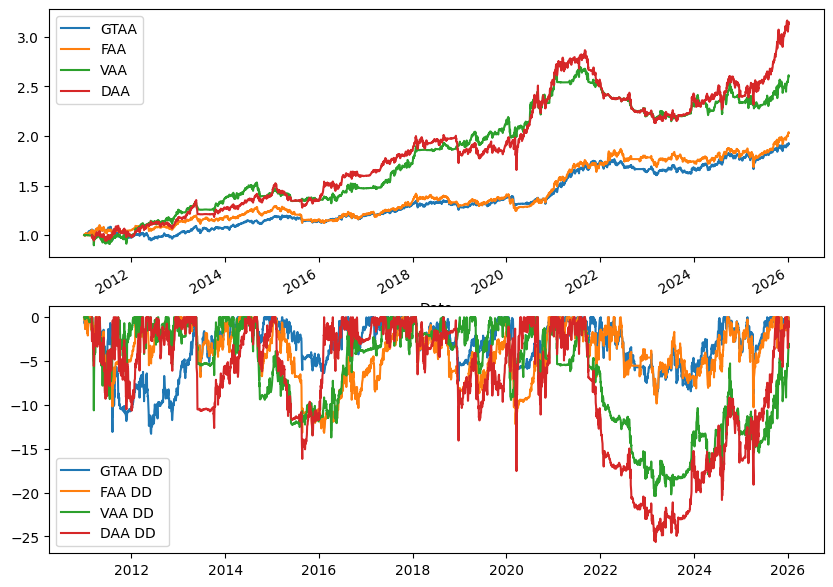

In [ ]:
plt.figure(figsize=(10,8))

# 수익곡선
plt.subplot(2,1,1)
gtaaCumReturn.plot(label="GTAA")
vaaCumReturn.plot(label="VAA")
daaCumReturn.plot(label="DAA")
plt.legend()

# dd 곡선
plt.subplot(2,1,2)
plt.plot(gtaaDD, label="GTAA DD")
plt.plot(vaaDD, label="VAA DD")
plt.plot(daaDD, label="DAA DD")
plt.legend()

plt.show()